# 04 — Calibration Audit

Question: when the model says 0.30, do 30% of those loans actually default?

PR-AUC and ROC-AUC measure ranking quality, not probability quality. If pricing decisions or expected-loss calculations consume the predicted probability directly, miscalibration costs real money. This notebook:

1. Plots a reliability diagram on the held-out test set.
2. Reports Brier score and expected calibration error (ECE).
3. Splits test in half: fits a Platt and an isotonic recalibrator on one half, evaluates on the other.
4. Compares before/after on the eval half.

In [1]:
import sys
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.calibration import (
    reliability_table, calibration_metrics,
    fit_platt, apply_platt, fit_isotonic, apply_isotonic,
)

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
ART = Path('../reports/artifacts')

y_te = pd.read_csv(ART / 'y_test.csv')['default'].to_numpy()
y_prob = np.load(ART / 'y_prob_lightgbm.npy')
print(f'test rows: {len(y_te)}, prevalence: {y_te.mean():.3f}, raw mean prob: {y_prob.mean():.3f}')

test rows: 10000, prevalence: 0.180, raw mean prob: 0.181


## Raw reliability

Quantile-binned: each bin has roughly equal mass, so the empirical rate has comparable noise across the curve.

In [2]:
tbl = reliability_table(y_te, y_prob, n_bins=12)
tbl.round(4)

,mean_predicted,fraction_positive,count
0,0.0000,0.0019,834
1,0.0012,0.0035,833
2,0.0024,0.0068,833
3,0.0084,0.0119,833
4,0.0144,0.0209,834
5,0.0264,0.0378,833
6,0.0708,0.0639,833
7,0.1128,0.1102,833
8,0.2086,0.1919,834
9,0.3301,0.3280,833


In [3]:
raw_metrics = calibration_metrics(y_te, y_prob)
print(f'Raw Brier: {raw_metrics["brier"]:.4f}')
print(f'Raw ECE  : {raw_metrics["ece"]:.4f}')

Raw Brier: 0.0810
Raw ECE  : 0.0080


## Recalibrate on held-out half

The original model was trained on `X_tr` (40k rows) and never saw `X_te` (10k rows). Splitting test in half gives a clean calibration set and a clean evaluation set.

In [4]:
rng = np.random.default_rng(0)
n = len(y_te)
idx = rng.permutation(n)
cal_idx, eval_idx = idx[: n // 2], idx[n // 2 :]

y_cal,  p_cal  = y_te[cal_idx],  y_prob[cal_idx]
y_eval, p_eval = y_te[eval_idx], y_prob[eval_idx]

platt = fit_platt(p_cal, y_cal)
iso   = fit_isotonic(p_cal, y_cal)

p_eval_platt = apply_platt(platt, p_eval)
p_eval_iso   = apply_isotonic(iso,   p_eval)

rows = []
for label, probs in [('raw', p_eval), ('platt', p_eval_platt), ('isotonic', p_eval_iso)]:
    m = calibration_metrics(y_eval, probs)
    rows.append({'method': label, **m})
comparison = pd.DataFrame(rows).set_index('method').round(4)
comparison

,brier,ece
method,,
raw,0.0832,0.0095
platt,0.0834,0.0124
isotonic,0.0831,0.0107


## Reliability diagram (full test set + recalibrated curves)

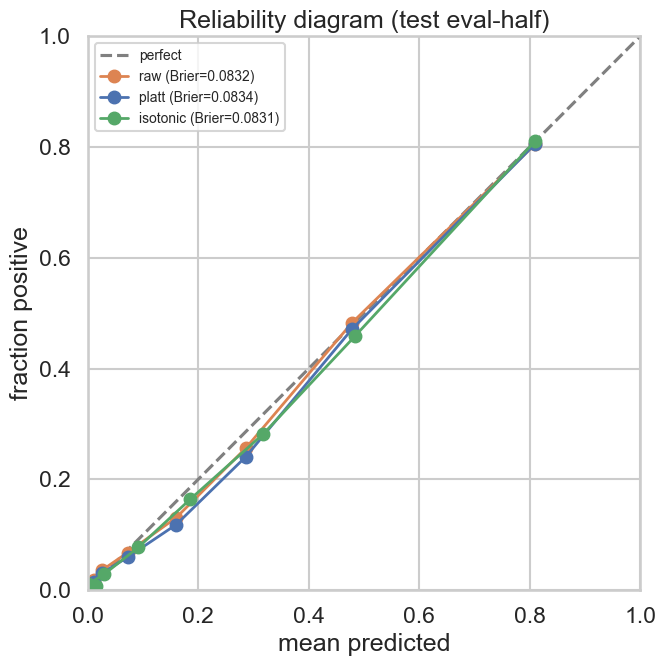

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect')
for label, probs, color in [
    ('raw',      p_eval,        '#dd8452'),
    ('platt',    p_eval_platt,  '#4c72b0'),
    ('isotonic', p_eval_iso,    '#55a868'),
]:
    t = reliability_table(y_eval, probs, n_bins=10)
    ax.plot(t['mean_predicted'], t['fraction_positive'], marker='o', color=color, lw=2,
            label=f"{label} (Brier={calibration_metrics(y_eval, probs)['brier']:.4f})")
ax.set_xlabel('mean predicted'); ax.set_ylabel('fraction positive')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Reliability diagram (test eval-half)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'reliability.png', dpi=120); plt.show()

## Histogram of predicted probabilities

If the raw model concentrates predictions near 0 with a thin tail past 0.5, that's the typical "under-confident" shape that LightGBM with regularization tends to produce on imbalanced data.

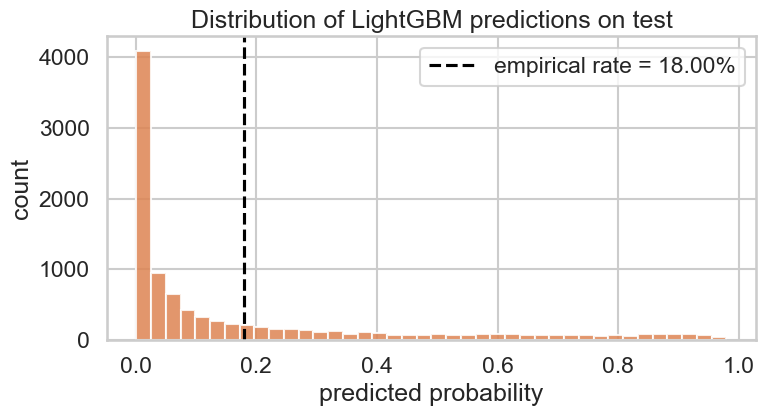

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(y_prob, bins=40, color='#dd8452', alpha=0.85)
ax.axvline(y_te.mean(), color='black', linestyle='--', label=f'empirical rate = {y_te.mean():.2%}')
ax.set_xlabel('predicted probability'); ax.set_ylabel('count')
ax.set_title('Distribution of LightGBM predictions on test')
ax.legend(); plt.tight_layout(); plt.savefig(FIG_DIR / 'prob_histogram.png', dpi=120); plt.show()

## Takeaways

- The reliability curve and Brier/ECE numbers tell us how trustable the *probability values* are, separate from how good the *ranking* is.
- Both Platt (parametric sigmoid) and isotonic (non-parametric monotone) are valid recalibration choices. Isotonic is more flexible but needs more data; Platt is more stable when calibration data is small.
- **Important**: recalibration only changes probabilities; it does not change ranking, so PR-AUC / ROC-AUC are unchanged. The cost-aware threshold from notebook 02 should be re-derived on the recalibrated probabilities for production use, since the threshold value is calibration-dependent.

## Cross-validated calibration

The recalibration above used a held-out half of the test set as calibration data. That's defensible — the model never saw test — but the cleanest practice is to fit calibrators on cross-validated probabilities from the **train** set, where each row's probability comes from a fold that didn't include it.

This refits the LightGBM pipeline 5 times (once per fold) on the train set, gets out-of-fold predictions, fits Platt and isotonic on those, and evaluates on the full test set.

In [7]:
from sklearn.model_selection import train_test_split
from src import RANDOM_STATE
from src.data import load_data
from src.features import engineer_features, split_xy
from src.calibration import cv_calibrated_probs
import joblib

df = engineer_features(load_data())
X, y = split_xy(df)
X_tr, X_te_full, y_tr, y_te_full = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
lgbm_pipe = joblib.load(ART / 'lightgbm_tuned.joblib')

print('Computing CV probs on train (this refits the pipeline 5 times)...')
p_tr_cv = cv_calibrated_probs(lgbm_pipe, X_tr, y_tr, cv=5, random_state=RANDOM_STATE)
print(f'CV prob range on train: [{p_tr_cv.min():.3f}, {p_tr_cv.max():.3f}]')

Computing CV probs on train (this refits the pipeline 5 times)...


CV prob range on train: [0.002, 0.959]


In [8]:
platt_cv = fit_platt(p_tr_cv, y_tr.to_numpy())
iso_cv   = fit_isotonic(p_tr_cv, y_tr.to_numpy())

# Evaluate every method on the same eval-half so rows are directly comparable.
p_eval_platt_cv = apply_platt(platt_cv, p_eval)
p_eval_iso_cv   = apply_isotonic(iso_cv, p_eval)

rows = []
for label, probs in [
    ('raw',                    p_eval),
    ('platt (test-half)',      p_eval_platt),
    ('isotonic (test-half)',   p_eval_iso),
    ('platt (CV-on-train)',    p_eval_platt_cv),
    ('isotonic (CV-on-train)', p_eval_iso_cv),
]:
    rows.append({'method': label, **calibration_metrics(y_eval, probs)})
comparison_full = pd.DataFrame(rows).set_index('method').round(4)
comparison_full

,brier,ece
method,,
raw,0.0832,0.0095
platt (test-half),0.0834,0.0124
isotonic (test-half),0.0831,0.0107
platt (CV-on-train),0.0833,0.0126
isotonic (CV-on-train),0.0847,0.0206


The CV-on-train calibrators are evaluated on the same eval-half as the test-half rows above, so the comparison is apples-to-apples. All five methods land within Brier noise of each other on this data, which is consistent with LightGBM being well-calibrated under these hyperparameters.